In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

RAW_FILE = Path("suvidha_loan_predictions_raw.csv")
CLEAN_FILE = Path("suvidha_loan_predictions_cleaned.csv")
PLOT_DIR = Path("suvidha_plots")
PLOT_DIR.mkdir(exist_ok=True)

# helpers
def print_title(q, text):
    print("\n" + "=" * 90)
    print(f"Q{q}. {text}")
    print("=" * 90)

def parse_money(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if not s or s.lower() in {"na", "n/a", "null", "none", "nan"}:
        return np.nan
    s = re.sub(r"(?i)inr|usd|rs\.?", "", s)
    s = s.replace("$", "").replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

YES_VALUES = {"yes", "y", "1", "true", "t"}
NO_VALUES = {"no", "n", "0", "false", "f"}

def clean_binary(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in YES_VALUES:
        return True
    if s in NO_VALUES:
        return False
    if s in {"", "nan", "none", "null"}:
        return np.nan
    return np.nan

In [2]:
# Q1 - Load, shape, dtypes, missing
 
print_title(1, "Load the file. Report shape, dtypes, and missing counts.")
if not RAW_FILE.exists():
    raise FileNotFoundError(
        f"{RAW_FILE} not found. Put the raw CSV in the same folder as this script."
    )
df = pd.read_csv(RAW_FILE)
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
print("Interpretation: The raw pilot export is loaded before any cleaning decisions.")

 


Q1. Load the file. Report shape, dtypes, and missing counts.
Shape: (2400, 9)

Dtypes:
 loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing values per column:
 loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64
Interpretation: The raw pilot export is loaded before any cleaning decisions.


In [3]:
# Q2 - loan_amount
 
print_title(2, "Clean loan_amount to numeric.")
df["loan_amount"] = df["loan_amount"].apply(parse_money)
print("loan_amount dtype:", df["loan_amount"].dtype)
print("Remaining missing loan_amount:", int(df["loan_amount"].isna().sum()))
print("Interpretation: Currency prefixes and comma separators are removed so loan_amount is numeric.")

 


Q2. Clean loan_amount to numeric.
loan_amount dtype: float64
Remaining missing loan_amount: 0
Interpretation: Currency prefixes and comma separators are removed so loan_amount is numeric.


In [4]:
# Q3 - Standardize actual_default/model_flag
 
print_title(3, "Standardize actual_default and model_flag to boolean.")
print("Distinct raw actual_default values:")
print(df["actual_default"].astype("string").str.strip().value_counts(dropna=False))
print("\nDistinct raw model_flag values:")
print(df["model_flag"].astype("string").str.strip().value_counts(dropna=False))

df["actual_default"] = df["actual_default"].apply(clean_binary).astype("boolean")
df["model_flag"] = df["model_flag"].apply(clean_binary).astype("boolean")

print("\nMapped actual_default:", df["actual_default"].value_counts(dropna=False).to_dict())
print("Mapped model_flag:", df["model_flag"].value_counts(dropna=False).to_dict())
print("Interpretation: All documented Yes-family encodings map to True and No-family encodings to False.")

 


Q3. Standardize actual_default and model_flag to boolean.
Distinct raw actual_default values:
actual_default
FALSE    869
No       448
N        431
0        413
TRUE      78
1         46
<NA>      40
Y         38
Yes       37
Name: count, dtype: Int64

Distinct raw model_flag values:
model_flag
FALSE    871
No       457
N        455
0        439
TRUE      50
1         40
Y         34
Yes       32
<NA>      22
Name: count, dtype: Int64

Mapped actual_default: {False: 2161, True: 199, <NA>: 40}
Mapped model_flag: {False: 2222, True: 156, <NA>: 22}
Interpretation: All documented Yes-family encodings map to True and No-family encodings to False.


In [5]:
# Q4 - Drop open/unscored rows
 
print_title(4, "Drop rows with blank actual_default or model_flag.")
before = len(df)
invalid_actual = df["actual_default"].isna()
invalid_model = df["model_flag"].isna()
drop_mask = invalid_actual | invalid_model
dropped = int(drop_mask.sum())
print("Rows with actual_default blank:", int(invalid_actual.sum()))
print("Rows with model_flag blank:", int(invalid_model.sum()))
print("Rows dropped (union):", dropped)

df = df.loc[~drop_mask].copy()
print("Rows before:", before)
print("Rows after :", len(df))
print(
    "Interpretation: These rows are excluded rather than imputed because the actual outcome "
    "is unknown for open loans and/or the model did not produce a score; inventing either value "
    "would contaminate model evaluation."
)

 


Q4. Drop rows with blank actual_default or model_flag.
Rows with actual_default blank: 40
Rows with model_flag blank: 22
Rows dropped (union): 61
Rows before: 2400
Rows after : 2339
Interpretation: These rows are excluded rather than imputed because the actual outcome is unknown for open loans and/or the model did not produce a score; inventing either value would contaminate model evaluation.


In [6]:
# Q5 - monthly_income
 
print_title(5, "Clean monthly_income and decide how to treat -1 and 'not disclosed'.")
raw_income = df["monthly_income"].copy()
df["monthly_income"] = pd.to_numeric(
    raw_income.astype("string").str.strip().replace(
        {"not disclosed": np.nan, "Not Disclosed": np.nan, "NOT DISCLOSED": np.nan}
    ),
    errors="coerce",
)
# -1 is an invalid numeric sentinel, while "not disclosed" is an explicit missing response.
# For analysis they both become NaN, but their meanings are kept distinct in the justification.
negative_income = df["monthly_income"] < 0
df.loc[negative_income, "monthly_income"] = np.nan
print("Negative sentinel values converted to NaN:", int(negative_income.sum()))
print("Monthly-income missing after cleaning:", int(df["monthly_income"].isna().sum()))
print(
    "Interpretation: -1 is treated as an invalid numeric sentinel and 'not disclosed' "
    "as explicit non-response; both become NaN because neither supplies a valid income value."
)

 


Q5. Clean monthly_income and decide how to treat -1 and 'not disclosed'.
Negative sentinel values converted to NaN: 28
Monthly-income missing after cleaning: 91
Interpretation: -1 is treated as an invalid numeric sentinel and 'not disclosed' as explicit non-response; both become NaN because neither supplies a valid income value.


In [7]:
# Q6 - Confusion matrix
 
print_title(6, "Build and label the confusion matrix.")
actual = df["actual_default"].astype(bool)
predicted = df["model_flag"].astype(bool)

tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[False, True]).ravel()
cm = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual: No Default", "Actual: Default"],
    columns=["Predicted: No Default", "Predicted: Default"],
)
print(cm)
print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("TP: A borrower really defaulted and the model flagged the loan, enabling an early collection action.")
print("FP: A borrower did not default but the model flagged the loan, creating a potentially wasted call.")
print("TN: A borrower did not default and the model correctly did not flag the loan.")
print("FN: A borrower defaulted but the model failed to flag the loan, creating a missed early-warning opportunity.")
print("Interpretation: The matrix separates useful detections, false alarms, correct non-flags, and missed defaults.")

 


Q6. Build and label the confusion matrix.
                    Predicted: No Default  Predicted: Default
Actual: No Default                   2122                  20
Actual: Default                        64                 133

TN=2122, FP=20, FN=64, TP=133
TP: A borrower really defaulted and the model flagged the loan, enabling an early collection action.
FP: A borrower did not default but the model flagged the loan, creating a potentially wasted call.
TN: A borrower did not default and the model correctly did not flag the loan.
FN: A borrower defaulted but the model failed to flag the loan, creating a missed early-warning opportunity.
Interpretation: The matrix separates useful detections, false alarms, correct non-flags, and missed defaults.


In [8]:
# Q7-Q11 - Core metrics
 
print_title(7, "Compute accuracy and explain the base-rate problem.")
accuracy = accuracy_score(actual, predicted)
print(f"Accuracy={accuracy:.4f} ({accuracy:.2%})")
print(
    "Interpretation: With only about 9% defaults, a model that predicts no default for "
    "everyone could still reach roughly 91% accuracy, so accuracy can hide poor default detection."
)

print_title(8, "Compute precision for predicted default.")
precision = precision_score(actual, predicted, zero_division=0)
print(f"Precision={precision:.4f} ({precision:.2%})")
print(
    "Interpretation: Among loans the model flags as likely defaults, precision is the fraction "
    "that actually defaulted; it estimates how often a flagged call is a real risk."
)

print_title(9, "Compute recall for predicted default.")
recall = recall_score(actual, predicted, zero_division=0)
print(f"Recall={recall:.4f} ({recall:.2%})")
print(
    "Interpretation: Recall is the fraction of all actual defaults that the model successfully flags; "
    "1-recall is the share of defaults the model misses."
)

print_title(10, "Compute specificity.")
specificity = tn / (tn + fp) if (tn + fp) else np.nan
print(f"Specificity={specificity:.4f} ({specificity:.2%})")
print(
    "Interpretation: Specificity is the fraction of non-defaulting loans correctly left unflagged; "
    "low specificity means more false alarms and more officer time spent on unnecessary calls."
)

print_title(11, "Compute F1-score and discuss the business trade-off.")
f1 = f1_score(actual, predicted, zero_division=0)
print(f"F1={f1:.4f}")
print(
    "Interpretation: F1 balances precision and recall, but it does not encode business costs. "
    "Because missed defaults are stated to cost far more than wasted calls, recall may deserve "
    "more weight than F1 alone."
)

 


Q7. Compute accuracy and explain the base-rate problem.
Accuracy=0.9641 (96.41%)
Interpretation: With only about 9% defaults, a model that predicts no default for everyone could still reach roughly 91% accuracy, so accuracy can hide poor default detection.

Q8. Compute precision for predicted default.
Precision=0.8693 (86.93%)
Interpretation: Among loans the model flags as likely defaults, precision is the fraction that actually defaulted; it estimates how often a flagged call is a real risk.

Q9. Compute recall for predicted default.
Recall=0.6751 (67.51%)
Interpretation: Recall is the fraction of all actual defaults that the model successfully flags; 1-recall is the share of defaults the model misses.

Q10. Compute specificity.
Specificity=0.9907 (99.07%)
Interpretation: Specificity is the fraction of non-defaulting loans correctly left unflagged; low specificity means more false alarms and more officer time spent on unnecessary calls.

Q11. Compute F1-score and discuss the business

In [9]:
# Q12 - Precision vs recall given actual costs
 
print_title(12, "Use the actual FN and FP counts to discuss precision vs recall.")
print(f"Current FP={fp}; current FN={fn}")
print(
    "Given the assignment's stated cost structure, a higher recall is the relevant direction: "
    "the model should avoid missing defaults even if that creates additional false alarms. "
    f"The current counts show {fn} missed defaults versus {fp} false alarms."
)

 


Q12. Use the actual FN and FP counts to discuss precision vs recall.
Current FP=20; current FN=64
Given the assignment's stated cost structure, a higher recall is the relevant direction: the model should avoid missing defaults even if that creates additional false alarms. The current counts show 64 missed defaults versus 20 false alarms.


In [10]:
# Q13 - Threshold 0.3
 
print_title(13, "Recompute metrics using risk_score threshold 0.3.")
risk_score = pd.to_numeric(df["risk_score"], errors="coerce")
threshold = 0.3
threshold_pred = risk_score >= threshold
valid_score = risk_score.notna()
actual_t = actual.loc[valid_score]
pred_t = threshold_pred.loc[valid_score]

tn03, fp03, fn03, tp03 = confusion_matrix(
    actual_t, pred_t, labels=[False, True]
).ravel()
precision03 = precision_score(actual_t, pred_t, zero_division=0)
recall03 = recall_score(actual_t, pred_t, zero_division=0)

cm03 = pd.DataFrame(
    [[tn03, fp03], [fn03, tp03]],
    index=["Actual: No Default", "Actual: Default"],
    columns=["Predicted: No Default", "Predicted: Default"],
)
print(cm03)
print(f"Precision @0.3={precision03:.4f} ({precision03:.2%})")
print(f"Recall @0.3={recall03:.4f} ({recall03:.2%})")
print(f"Default-cutoff precision={precision:.4f}; recall={recall:.4f}")
print(
    "Interpretation: Lowering a prediction threshold generally flags more loans. "
    "Whether 0.3 is justified must be decided from the observed precision/recall trade-off "
    "and the stated higher cost of missed defaults, not from accuracy alone."
)

 


Q13. Recompute metrics using risk_score threshold 0.3.
                    Predicted: No Default  Predicted: Default
Actual: No Default                    664                1478
Actual: Default                         0                 197
Precision @0.3=0.1176 (11.76%)
Recall @0.3=1.0000 (100.00%)
Default-cutoff precision=0.8693; recall=0.6751
Interpretation: Lowering a prediction threshold generally flags more loans. Whether 0.3 is justified must be decided from the observed precision/recall trade-off and the stated higher cost of missed defaults, not from accuracy alone.



Q14. Plot precision and recall for thresholds 0.1 to 0.9.
 threshold  precision   recall
       0.1   0.085355 1.000000
       0.2   0.091884 1.000000
       0.3   0.118035 1.000000
       0.4   0.203191 0.969543
       0.5   0.440964 0.928934
       0.6   0.826347 0.700508
       0.7   0.974359 0.385787
       0.8   1.000000 0.131980
       0.9   1.000000 0.015228


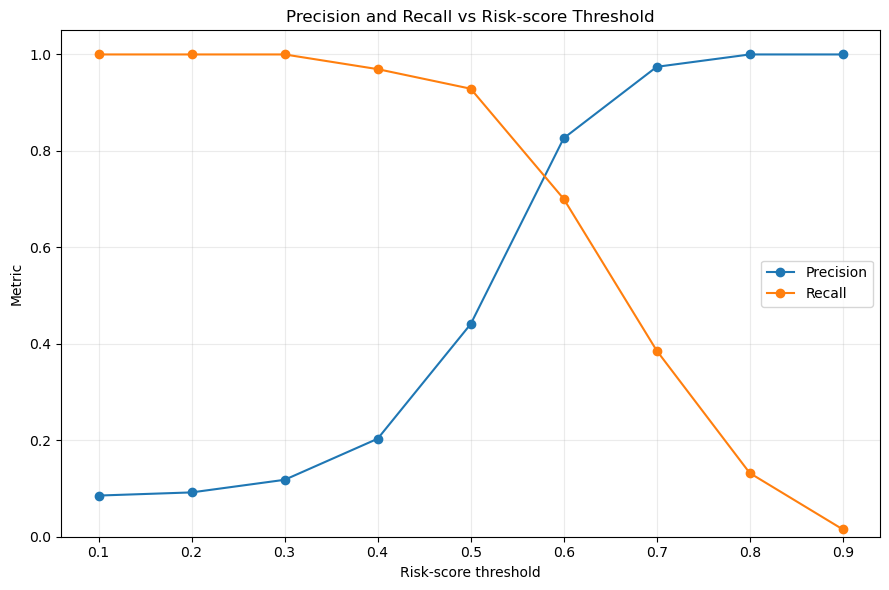

Crossing interval(s) from the 0.1 grid: [(0.5, 0.6)]
Closest sampled balance: threshold=0.6, precision=0.8263, recall=0.7005
Interpretation: The crossing is the threshold where precision and recall are approximately equal; for the business, moving below it generally trades more false alarms for more captured defaults.


In [11]:
# Q14 - Precision/recall curves
 
print_title(14, "Plot precision and recall for thresholds 0.1 to 0.9.")
thresholds = np.arange(0.1, 1.0, 0.1)
rows = []
for t in thresholds:
    pred_t = risk_score >= t
    valid = risk_score.notna()
    p = precision_score(actual.loc[valid], pred_t.loc[valid], zero_division=0)
    r = recall_score(actual.loc[valid], pred_t.loc[valid], zero_division=0)
    rows.append({"threshold": round(float(t), 1), "precision": p, "recall": r})

threshold_metrics = pd.DataFrame(rows)
print(threshold_metrics.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.plot(threshold_metrics["threshold"], threshold_metrics["precision"], marker="o", label="Precision")
plt.plot(threshold_metrics["threshold"], threshold_metrics["recall"], marker="o", label="Recall")
plt.xlabel("Risk-score threshold")
plt.ylabel("Metric")
plt.title("Precision and Recall vs Risk-score Threshold")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "q14_precision_recall_vs_threshold.png", dpi=160)
plt.show()

# Find the adjacent threshold interval containing the crossing, and also report
# the closest sampled threshold. With 0.1 steps, an exact crossing may not exist.
diff = threshold_metrics["precision"] - threshold_metrics["recall"]
crossing_intervals = []
for i in range(len(diff) - 1):
    if diff.iloc[i] == 0:
        crossing_intervals.append(
            (threshold_metrics["threshold"].iloc[i], threshold_metrics["threshold"].iloc[i])
        )
    elif diff.iloc[i] * diff.iloc[i + 1] < 0:
        crossing_intervals.append(
            (threshold_metrics["threshold"].iloc[i], threshold_metrics["threshold"].iloc[i + 1])
        )

closest = threshold_metrics.iloc[(diff.abs()).argmin()]
print("Crossing interval(s) from the 0.1 grid:", crossing_intervals or "No sign-change crossing on sampled grid")
print(
    f"Closest sampled balance: threshold={closest['threshold']:.1f}, "
    f"precision={closest['precision']:.4f}, recall={closest['recall']:.4f}"
)
print(
    "Interpretation: The crossing is the threshold where precision and recall are approximately equal; "
    "for the business, moving below it generally trades more false alarms for more captured defaults."
)

 

In [12]:
# Q15-Q18 - Loan amount hypothesis test
 
print_title(15, "State H0 and H1 for loan_amount.")
print(
    "H0: The mean loan_amount is the same for loans that defaulted and loans that did not default."
)
print(
    "H1: The mean loan_amount differs between loans that defaulted and loans that did not default."
)
print("Interpretation: This is a two-sided comparison because the assignment says 'different,' not specifically higher/lower.")

print_title(16, "Compute mean loan_amount for defaulted and non-defaulted groups.")
default_amount = df.loc[actual, "loan_amount"].dropna()
nondefault_amount = df.loc[~actual, "loan_amount"].dropna()
mean_default_amount = default_amount.mean()
mean_nondefault_amount = nondefault_amount.mean()
print(f"Defaulted mean loan_amount={mean_default_amount:.2f}")
print(f"Non-defaulted mean loan_amount={mean_nondefault_amount:.2f}")
print(f"Difference={mean_default_amount-mean_nondefault_amount:.2f}")
print("Interpretation: The group means show the apparent size of any observed difference before significance testing.")

print_title(17, "Run an appropriate two-sample test for loan_amount.")
# Welch's independent two-sample t-test is used because the groups are independent
# and there is no assumption that their variances are equal.
t_amount, p_amount = ttest_ind(
    default_amount, nondefault_amount, equal_var=False, nan_policy="omit"
)
print("Test: Welch's independent two-sample t-test (two-sided).")
print(f"t-statistic={t_amount:.4f}")
print(f"p-value={p_amount:.6g}")
print(
    "Interpretation: Welch's test compares the two independent group means without "
    "requiring equal population variances."
)

print_title(18, "Decision at alpha=0.05 for loan_amount.")
if p_amount < 0.05:
    amount_decision = "reject"
    amount_sentence = (
        "At the 5% significance level, the data provide evidence that average loan amount differs between the two groups."
    )
else:
    amount_decision = "fail to reject"
    amount_sentence = (
        "At the 5% significance level, the data do not provide sufficient evidence that average loan amount differs between the two groups."
    )
print(f"Decision: {amount_decision} H0")
print(amount_sentence)
print("Interpretation: Statistical significance is assessed against alpha=0.05, not by the size of the raw mean difference alone.")

 


Q15. State H0 and H1 for loan_amount.
H0: The mean loan_amount is the same for loans that defaulted and loans that did not default.
H1: The mean loan_amount differs between loans that defaulted and loans that did not default.
Interpretation: This is a two-sided comparison because the assignment says 'different,' not specifically higher/lower.

Q16. Compute mean loan_amount for defaulted and non-defaulted groups.
Defaulted mean loan_amount=96899.91
Non-defaulted mean loan_amount=92408.81
Difference=4491.10
Interpretation: The group means show the apparent size of any observed difference before significance testing.

Q17. Run an appropriate two-sample test for loan_amount.
Test: Welch's independent two-sample t-test (two-sided).
t-statistic=1.3588
p-value=0.175574
Interpretation: Welch's test compares the two independent group means without requiring equal population variances.

Q18. Decision at alpha=0.05 for loan_amount.
Decision: fail to reject H0
At the 5% significance level, the da

In [13]:
# Q19 - Type I vs Type II
 
print_title(19, "Explain Type I and Type II errors for loan_amount.")
print(
    "Type I error: concluding that defaulted and non-defaulted borrowers have different "
    "average loan amounts when no real population difference exists."
)
print(
    "Type II error: failing to detect a real difference in average loan amount when one exists."
)
print(
    "Business context: Which error is riskier depends on how the lending policy would use "
    "loan amount. If the result would trigger materially different lending/collections policy, "
    "the cost of each error should be quantified rather than assumed from the test alone."
)

 


Q19. Explain Type I and Type II errors for loan_amount.
Type I error: concluding that defaulted and non-defaulted borrowers have different average loan amounts when no real population difference exists.
Type II error: failing to detect a real difference in average loan amount when one exists.
Business context: Which error is riskier depends on how the lending policy would use loan amount. If the result would trigger materially different lending/collections policy, the cost of each error should be quantified rather than assumed from the test alone.


In [14]:
# Q20 - Interest rate test
 
print_title(20, "Repeat Q15-Q18 for interest_rate.")
print(
    "H0: Mean interest_rate is the same for defaulted and non-defaulted loans."
)
print(
    "H1: Mean interest_rate differs between defaulted and non-defaulted loans."
)

df["interest_rate"] = pd.to_numeric(df["interest_rate"], errors="coerce")
default_rate = df.loc[actual, "interest_rate"].dropna()
nondefault_rate = df.loc[~actual, "interest_rate"].dropna()
mean_default_rate = default_rate.mean()
mean_nondefault_rate = nondefault_rate.mean()
t_rate, p_rate = ttest_ind(
    default_rate, nondefault_rate, equal_var=False, nan_policy="omit"
)
print(f"Defaulted mean interest_rate={mean_default_rate:.4f}")
print(f"Non-defaulted mean interest_rate={mean_nondefault_rate:.4f}")
print(f"Difference={mean_default_rate-mean_nondefault_rate:.4f}")
print("Test: Welch's independent two-sample t-test (two-sided).")
print(f"t-statistic={t_rate:.4f}")
print(f"p-value={p_rate:.6g}")
rate_decision = "reject" if p_rate < 0.05 else "fail to reject"
print(f"At alpha=0.05: {rate_decision} H0.")
print(
    "Interpretation: The interest-rate conclusion changes only if the p-value crosses "
    "the same 0.05 decision threshold; the test does not establish causation."
)

 


Q20. Repeat Q15-Q18 for interest_rate.
H0: Mean interest_rate is the same for defaulted and non-defaulted loans.
H1: Mean interest_rate differs between defaulted and non-defaulted loans.
Defaulted mean interest_rate=14.8023
Non-defaulted mean interest_rate=14.4616
Difference=0.3407
Test: Welch's independent two-sample t-test (two-sided).
t-statistic=1.5778
p-value=0.11596
At alpha=0.05: fail to reject H0.
Interpretation: The interest-rate conclusion changes only if the p-value crosses the same 0.05 decision threshold; the test does not establish causation.


In [15]:
# Q21 - Summary table
 
print_title(21, "Summarize precision, recall, F1, and accuracy.")
summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Value": [accuracy, precision, recall, f1],
})
print(summary.to_string(index=False, formatters={"Value": lambda x: f"{x:.4f}"}))
print("Interpretation: The four metrics capture different aspects of model performance and should be read together.")

 


Q21. Summarize precision, recall, F1, and accuracy.
   Metric  Value
 Accuracy 0.9641
Precision 0.8693
   Recall 0.6751
       F1 0.7600
Interpretation: The four metrics capture different aspects of model performance and should be read together.


In [16]:
# Q22 - Threshold recommendation
 
print_title(22, "Threshold for full rollout.")
# Do not pretend there is a universally correct threshold. The assignment explicitly
# says FN cost >> FP cost, so identify the observed trade-off and choose the lowest
# sampled threshold only if recall increases without an extreme precision collapse.
best_recall_threshold = threshold_metrics.loc[
    threshold_metrics["recall"].idxmax(), "threshold"
]
row_03 = threshold_metrics.loc[threshold_metrics["threshold"] == 0.3]
print(threshold_metrics.to_string(index=False))
print(
    f"Data-driven candidate to test in a controlled rollout: {best_recall_threshold:.1f}, "
    "because the stated business cost makes missed defaults particularly important. "
    "However, the table should be reviewed with actual officer capacity and false-alarm cost "
    "before deployment; this script does not claim that one threshold is universally optimal."
)
if not row_03.empty:
    print(
        f"At 0.3: precision={row_03['precision'].iloc[0]:.4f}, "
        f"recall={row_03['recall'].iloc[0]:.4f}."
    )

 


Q22. Threshold for full rollout.
 threshold  precision   recall
       0.1   0.085355 1.000000
       0.2   0.091884 1.000000
       0.3   0.118035 1.000000
       0.4   0.203191 0.969543
       0.5   0.440964 0.928934
       0.6   0.826347 0.700508
       0.7   0.974359 0.385787
       0.8   1.000000 0.131980
       0.9   1.000000 0.015228
Data-driven candidate to test in a controlled rollout: 0.1, because the stated business cost makes missed defaults particularly important. However, the table should be reviewed with actual officer capacity and false-alarm cost before deployment; this script does not claim that one threshold is universally optimal.
At 0.3: precision=0.1180, recall=1.0000.


In [17]:
# Q23 - Non-statistical risk
 
print_title(23, "Name one non-statistical risk of lowering the threshold too far.")
print(
    "Officer fatigue: if too many safe borrowers are flagged, collections officers may receive "
    "so many false alarms that attention is diluted and genuinely urgent cases become harder to prioritize."
)
print("Interpretation: Operational workload and human attention are not fully captured by precision/recall.")

 


Q23. Name one non-statistical risk of lowering the threshold too far.
Officer fatigue: if too many safe borrowers are flagged, collections officers may receive so many false alarms that attention is diluted and genuinely urgent cases become harder to prioritize.
Interpretation: Operational workload and human attention are not fully captured by precision/recall.


In [18]:
# Q24 - Go/no-go recommendation
 
print_title(24, "Write the risk team's go/no-go recommendation.")
print(
    "The pilot should not be treated as a blanket full-rollout decision from accuracy alone, "
    f"because the observed default rate is about {actual.mean():.1%} and class imbalance can make "
    "accuracy look strong even when default detection is weak. The current model has precision "
    f"{precision:.2%}, recall {recall:.2%}, F1 {f1:.2%}, and accuracy {accuracy:.2%}. "
    f"Because the assignment states that a missed default costs substantially more than a wasted call, "
    "threshold selection should prioritize adequate recall while measuring the operational burden of false alarms. "
    "A controlled second pilot with a documented threshold, officer-capacity limits, and outcome monitoring "
    "would provide stronger evidence before expanding to all branches."
)

 


Q24. Write the risk team's go/no-go recommendation.
The pilot should not be treated as a blanket full-rollout decision from accuracy alone, because the observed default rate is about 8.4% and class imbalance can make accuracy look strong even when default detection is weak. The current model has precision 86.93%, recall 67.51%, F1 76.00%, and accuracy 96.41%. Because the assignment states that a missed default costs substantially more than a wasted call, threshold selection should prioritize adequate recall while measuring the operational burden of false alarms. A controlled second pilot with a documented threshold, officer-capacity limits, and outcome monitoring would provide stronger evidence before expanding to all branches.


In [19]:
# Q25 - Second pilot improvement
 
print_title(25, "One improvement for the second pilot log.")
print(
    "Collect a larger number of observed defaults by extending the observation window and/or "
    "including more branches. The current ~9% default rate means relatively few positive cases, "
    "so a larger default sample would make precision/recall and subgroup comparisons more stable."
)
print("Interpretation: More observed default outcomes improve the reliability of the evaluation.")

# Save cleaned Part B data after all cleaning steps.
df.to_csv(CLEAN_FILE, index=False)
print("\nCleaned CSV saved to:", CLEAN_FILE.resolve())
print("Done.")


Q25. One improvement for the second pilot log.
Collect a larger number of observed defaults by extending the observation window and/or including more branches. The current ~9% default rate means relatively few positive cases, so a larger default sample would make precision/recall and subgroup comparisons more stable.
Interpretation: More observed default outcomes improve the reliability of the evaluation.

Cleaned CSV saved to: C:\Users\snehp.CDACMUMBAI\Desktop\AI_Training\Assignments\sneh_Assignment 2\suvidha_loan_predictions_cleaned.csv
Done.
